# 第 22 章首次 PyTorch
全部直线数据为原创教学设定。固定 CPU、种子 42、120 轮，主程序先生成图。

In [1]:
import torch,numpy as np
print("PyTorch",torch.__version__)
array=np.array([1.,2.],dtype=np.float32)
tensor=torch.from_numpy(array)
tensor[0]=9
print("共享",array)
print("形状/类型/设备",tensor.shape,tensor.dtype,tensor.device)

PyTorch 2.9.0+cpu
共享 [9. 2.]
形状/类型/设备 torch.Size([2]) torch.float32 cpu


In [2]:
from examples.torch_core import autograd_demo
print(autograd_demo())

{'prediction': 5.5, 'loss': 2.25, 'gradients': {'W1': [[6.0, 0.0], [12.0, 0.0]], 'b1': [6.0, 0.0], 'W2': [7.5, 0.0], 'b2': 3.0}}


In [3]:
from examples.torch_core import train_model
model,x,y,predicted,records,summary=train_model()
print({k:v for k,v in summary.items() if not isinstance(v,list)})

{'seed': 42, 'device': 'cpu', 'torch': '2.9.0+cpu', 'dtype': 'float32', 'epochs': 120, 'learning_rate': 0.1, 'batch_size': 32, 'train_rows': 32, 'test_rows': 9, 'initial_train_MSE': 0.5539245009422302, 'final_train_MSE': 0.0015469396021217108, 'test_MSE': 0.0018987195799127221, 'weight': 2.009538173675537, 'bias': 1.0053625106811523}


In [4]:
print("首轮",records[1])
print("末轮",records[-1])
print("-1/0/1 预测",summary["demo_predictions"])

首轮 {'epoch': 1, 'train_loss': 0.4767700135707855}
末轮 {'epoch': 120, 'train_loss': 0.0015469396021217108}
-1/0/1 预测 [-1.0041756629943848, 1.0053625106811523, 3.0149006843566895]


In [5]:
layer=torch.nn.Linear(1,1)
layer.eval()
print("eval仍求导",layer(torch.ones(1,1)).requires_grad)
with torch.no_grad():
    print("no_grad关闭求导",layer(torch.ones(1,1)).requires_grad)

eval仍求导 True
no_grad关闭求导 False


In [6]:
w=torch.tensor(2.,requires_grad=True)
for _ in range(2):
    (w*3-1).square().backward()
print("累计梯度",w.grad.item())
w.grad=None
(w*3-1).square().backward()
print("清除后",w.grad.item())

累计梯度 60.0
清除后 30.0


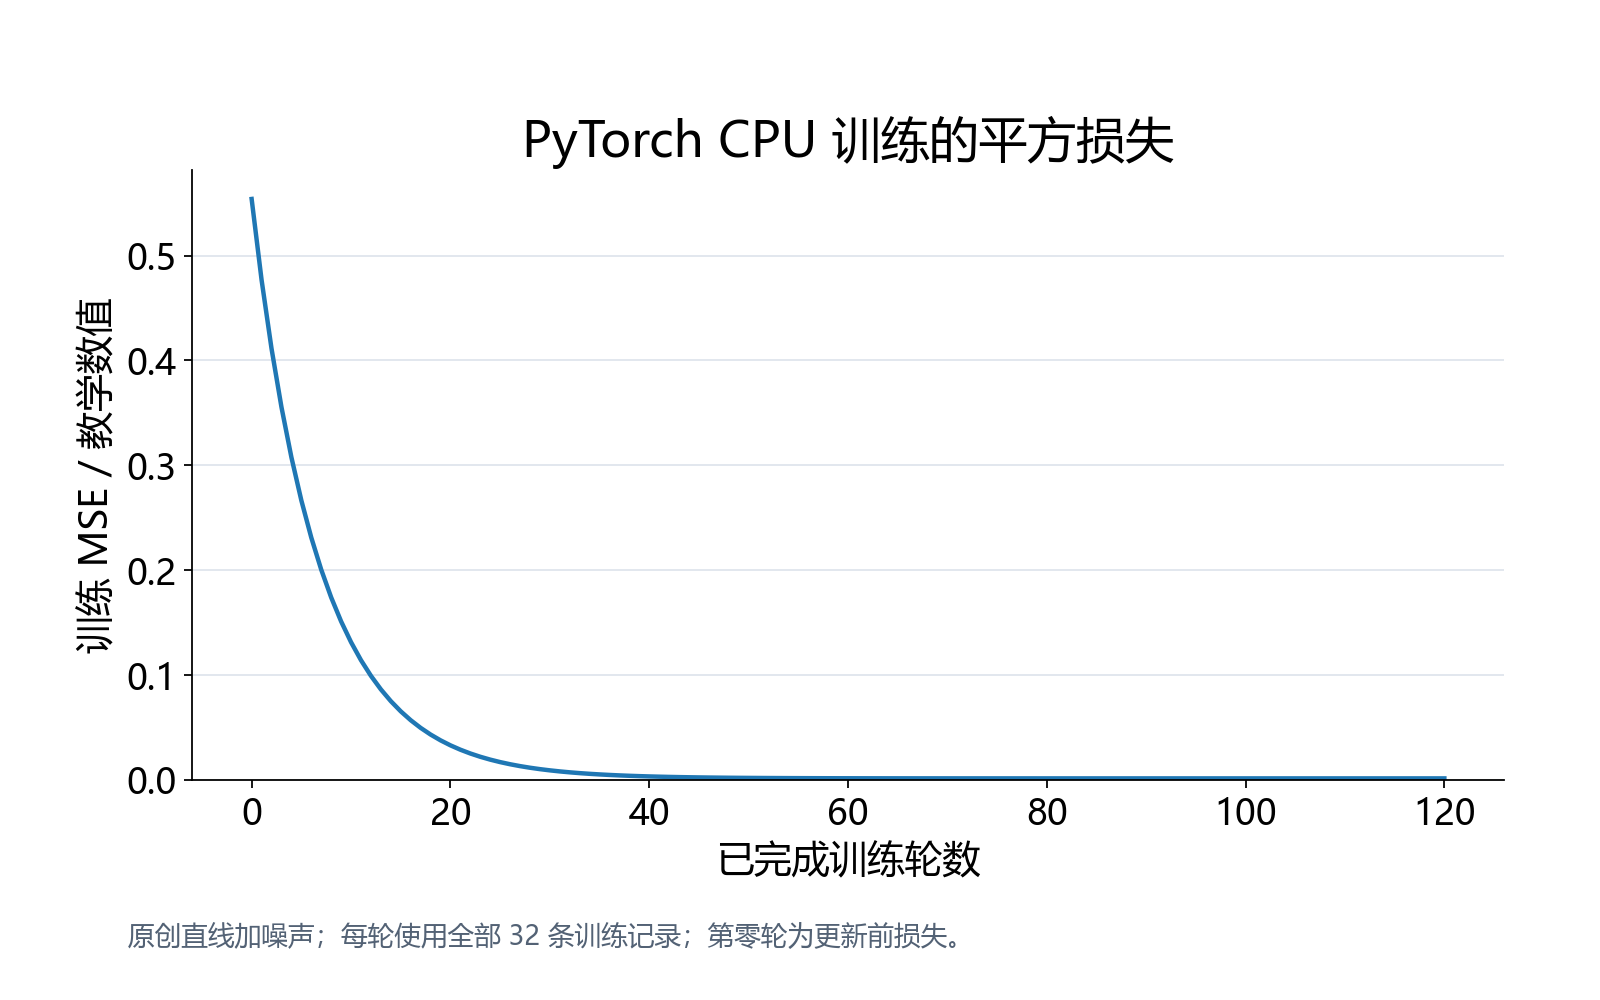

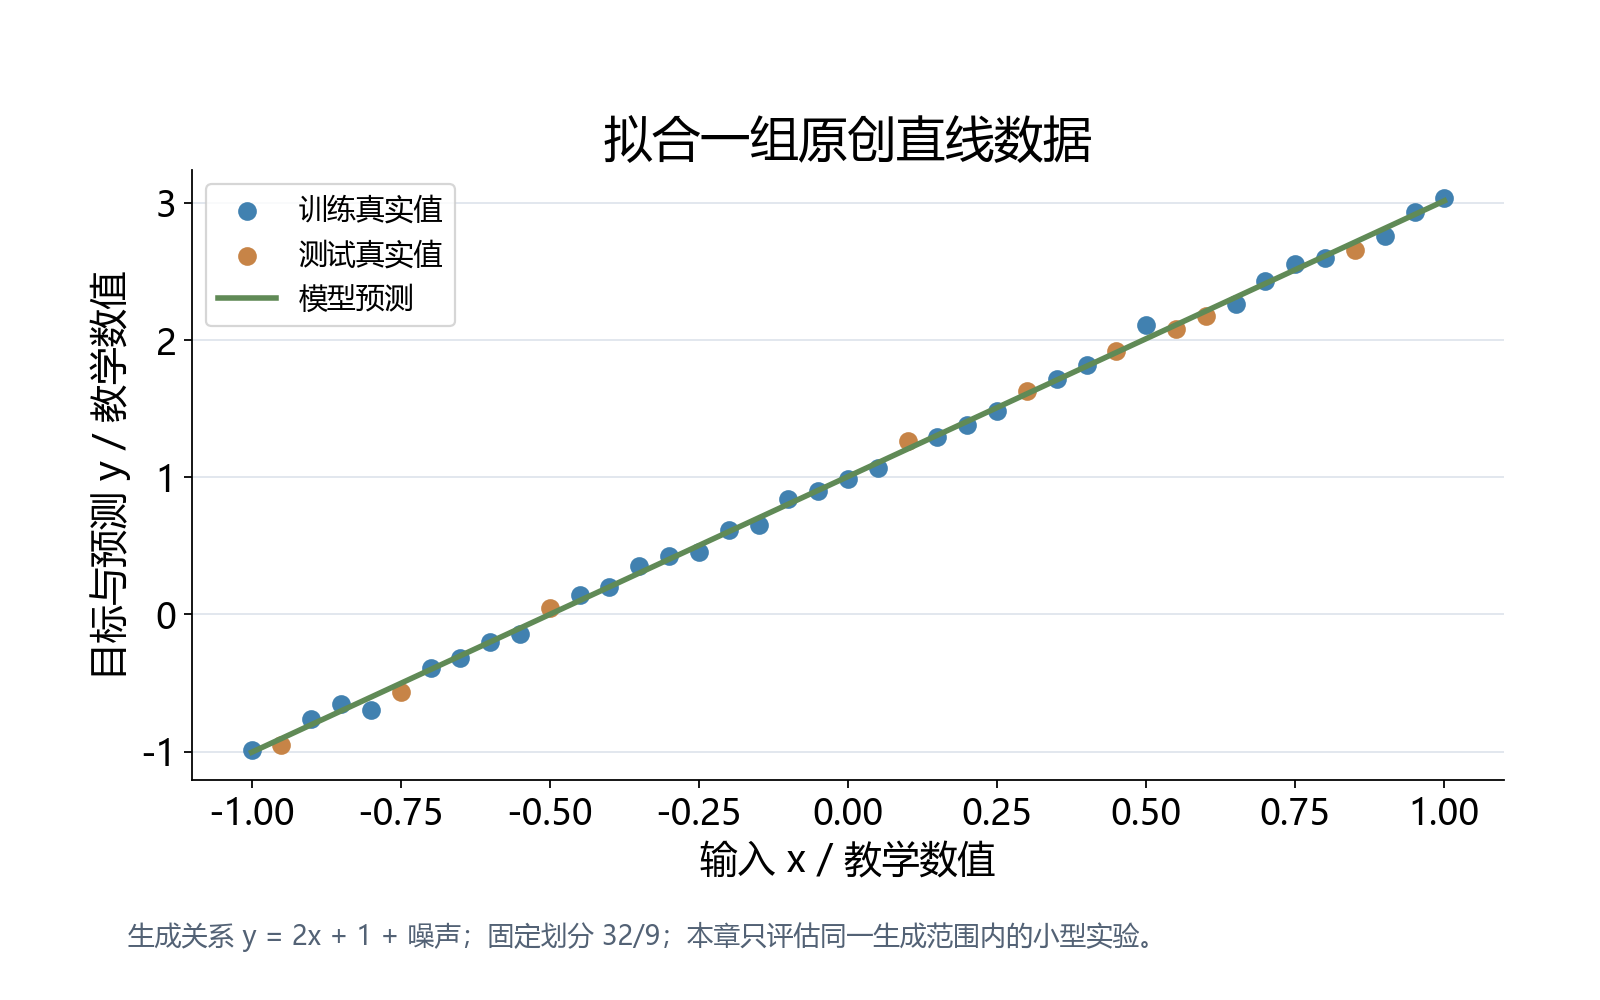

In [7]:
from IPython.display import display,Image
for name in ["training-loss","fitted-line"]:
    display(Image(filename=f"assets/{name}.png",width=700))